# LEZIONE 03 - ESEMPI APPLICAZIONE VISITA DFS

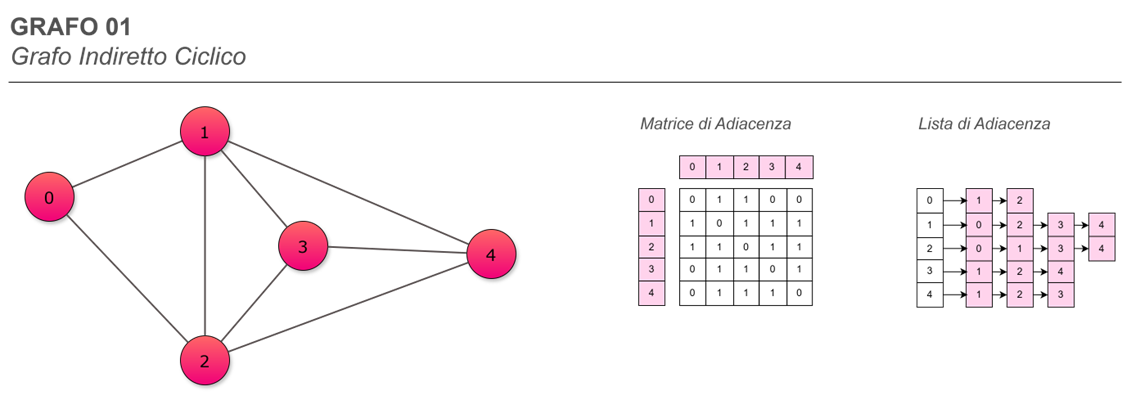

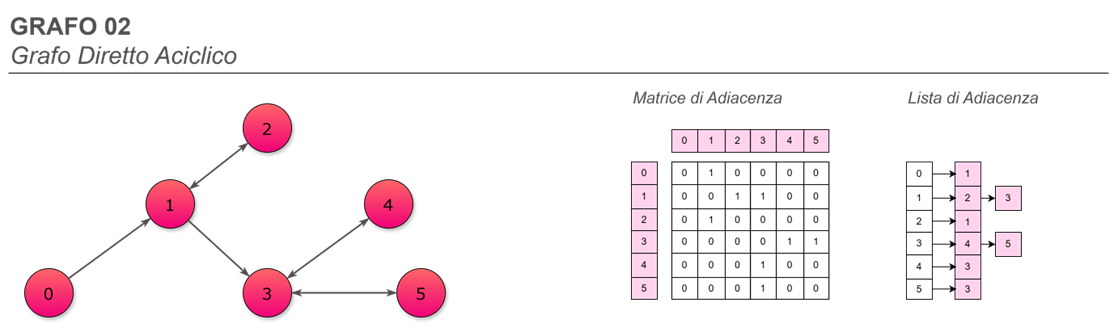

## Codice Python

In [1]:
import numpy as np

In [2]:
# -*- coding: utf-8 -*-
"""
LEZIONE 03 - ESEMPI DI APPLICAZIONE VISITA DFS

Algoritmi di utilita' tramite uso di DFS
    - Costruzione Vettore dei Padri
    - Ricerca Cammino - Iterativo
    - Ricerca Cammino - Ricorsivo
    
"""


" ALGORITMI *****************************************************************"


# COSTRUZIONE VETTORE DEI PADRI
def vettorePadri(u,G):                                      # T(n)
    def DFSricors(x):                                       # S(n)
        for y in G[x]:                                      # k*Θ(1)+Θ(1)
            if P[y]==-1:                                    # Θ(1)
                P[y]=x                                      # Θ(1)
                DFSricors(y)                                # S(v)
                
    P=[-1 for v in G]                                       # Θ(n)
    P[u]=u                                                  # Θ(1)
    DFSricors(u)                                            # S(n)
    return P                                                # Θ(1)
# Costo Computazionale: Θ(n+m) - CASO PEGGIORE/MIGLIORE



# RICERCA CAMMINO - Algoritmo ITERATIVO
def ricercaCammino_Iter(y,P):                               # T(n)
    if P[y]==-1: return []                                  # Θ(1)
    path=[]                                                 # Θ(1)
    while P[y]!=y:                                          # n*Θ(1)+Θ(1)
        path.append(y)                                      # Θ(1)
        y=P[y]                                              # Θ(1)
    path.append(y)                                          # Θ(1)
    path.reverse()                                          # Θ(n)
    return path                                             # Θ(1)
# Costo Computazionale: O(n)   - CASO PEGGIORE
#                       Ω(1)   - CASO MIGLIORE      



# RICERCA CAMMINO - Algoritmo RICORSIVO
def ricercaCammino_Ricors(y,P):                             # T(n)
    if P[y]==-1: return []                                  # Θ(1)
    if P[y]==y: return [y]                                  # Θ(1)
    return ricercaCammino_Ricors(P[y], P) + [y]             # T(n-1)
# Costo Computazionale: O(n)   - CASO PEGGIORE
#                       Ω(1)   - CASO MIGLIORE      



# RICERCA CICLI - Grafi NON DIRETTI
def ricercaCicli(u,G):                                      # T(n,m)
    def DFSciclo(u):                                        # S(n,m)
        vis[u]=1                                            # Θ(1)
        for v in G[u]:                                      # k*Θ(1)+Θ(1)
            if v!=P[u]:                                     # Θ(1)
                if vis[v]==0:                               # Θ(1)
                    P[v]=u                                  # Θ(1)
                    x=DFSciclo(v)                           # S(n-1,k)
                    if x==True: return True                 # Θ(1)
                else: return True                           # Θ(1)
        return False                                        # Θ(1)
        
    vis=[0 for v in G]                                      # Θ(n+m)
    P=[-1 for v in G]                                       # Θ(n+m)
    P[u]=u                                                  # Θ(1)
    return DFSciclo(u)                                      # S(n,m)
# Costo Computazionale: O(n+m)   - CASO PEGGIORE
#                       Ω(1)     - CASO MIGLIORE    



# BI-COLORAZIONE - Grafi NON DIRETTI
def biColorazione(u,G):
    def DFScolor(u):
        if P[u]==u: vis[u]=1
        else: 
            vis[u]=1
            if vis[P[u]]==1: vis[u]=2
        for v in G[u]:
            if v!=P[u]:
                if vis[v]==0:
                    P[v]=u
                    x=DFScolor(v)
                    if x==False: return False
                else:
                    if vis[v]==vis[u]: return False
        return True
    
    vis=[0 for v in G]
    P=[-1 for v in G]
    P[u]=u
    return DFScolor(u)



" ESEMPI ********************************************************************"

"""
Iniziamo, per semplicita', con un esempio puramente numerico...

"""

# LISTE DI ADIACENZA

'Grafo Ciclico' 
L_gc=[[1,2],
      [0,2,3,4],
      [0,1,3,4],
      [1,2,4],
      [1,2,3]]

'Grafo Aciclico' 
L_ga=[[1],
      [2,3],
      [1],
      [4,5],
      [3],
      [3]]

# MATRICE DI ADIACENZA

'Grafo Ciclico'
M_gc=[[0,1,1,0,0], # Riga di adiacenza del nodo 0
      [1,0,1,1,1], # Riga di adiacenza del nodo 1
      [1,1,0,1,1], # Riga di adiacenza del nodo 2
      [0,1,1,0,1], # Riga di adiacenza del nodo 3
      [0,1,1,1,0]] # Riga di adiacenza del nodo 4

'Grafo Aciclico'
M_ga=[[0,1,0,0,0,0], # Riga di adiacenza del nodo 0
      [0,0,1,1,0,0], # Riga di adiacenza del nodo 1
      [0,1,0,0,0,0], # Riga di adiacenza del nodo 2
      [0,0,0,0,1,1], # Riga di adiacenza del nodo 3
      [0,0,0,1,0,0], # Riga di adiacenza del nodo 4
      [0,0,0,1,0,0]] # Riga di adiacenza del nodo 5


# COSTRUZIONE VETTORE DEI PADRI
vp_gc=vettorePadri(0,L_gc)
print("Vettore dei Padri - Grafo Ciclico: " + str(vp_gc) + "\n")
vp_ga=vettorePadri(0,L_ga)
print("Vettore dei Padri - Grafo Aciclico: " + str(vp_ga) + "\n")

# RICERCA CAMMINO - Algoritmo ITERATIVO
cm_gc=ricercaCammino_Iter(4,vp_gc)
print("Cammino iterativo - Grafo Ciclico: " + str(cm_gc) + "\n")
cm_ga=ricercaCammino_Iter(4,vp_ga)
print("Cammino iterativo - Grafo Aciclico: " + str(cm_ga) + "\n")

# RICERCA CAMMINO - Algoritmo RICORSIVO
cm_gc=ricercaCammino_Ricors(4,vp_gc)
print("Cammino ricorsivo - Grafo Ciclico: " + str(cm_gc) + "\n")
cm_ga=ricercaCammino_Ricors(4,vp_ga)
print("Cammino ricorsivo - Grafo Aciclico: " + str(cm_ga) + "\n")

# RICERCA CICLI
rc_gc=ricercaCicli(0,L_gc)
print("Ricerca Cicli - Grafo Ciclico: " + str(rc_gc) + "\n")
rc_ga=ricercaCicli(0,L_ga)
print("Ricerca Cicli - Grafo Aciclico: " + str(rc_ga) + "\n")

# CONTROLLO BICOLORAZIONE
bc_gc=biColorazione(0,L_gc)
print("Controllo Colorazione - Grafo Ciclico: " + str(bc_gc) + "\n")
bc_ga=biColorazione(0,L_ga)
print("Controllo Colorazione - Grafo Aciclico: " + str(bc_ga) + "\n")

Vettore dei Padri - Grafo Ciclico: [0, 0, 1, 2, 3]

Vettore dei Padri - Grafo Aciclico: [0, 0, 1, 1, 3, 3]

Cammino iterativo - Grafo Ciclico: [0, 1, 2, 3, 4]

Cammino iterativo - Grafo Aciclico: [0, 1, 3, 4]

Cammino ricorsivo - Grafo Ciclico: [0, 1, 2, 3, 4]

Cammino ricorsivo - Grafo Aciclico: [0, 1, 3, 4]

Ricerca Cicli - Grafo Ciclico: True

Ricerca Cicli - Grafo Aciclico: False

Controllo Colorazione - Grafo Ciclico: False

Controllo Colorazione - Grafo Aciclico: True

